## Imports

In [5]:
# import the libraries used in this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [6]:
# load the dataset from excel
df = pd.read_excel('../data/stock_snapshot.xlsx', header=1)
df.head()

c:\Users\NelsonP\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,ARM,REF,DESCRICAO,TAMANHO,LOCALIZACAO,QUANTIDADE,PRECO MEDIO,PRECO3 IVA,TOTAL,COD MARCA,MARCA,FAMILIA,GRUPO,TIPO ARTIGO,COD SITUACAO,CAMPO USER2
0,1,0000188-ES14A,Placa para porta fatos - Poliestereno ES14 Azu...,UNI,NaN,1500,"0,08","0,07995",120,734,Wesley - Diversos,WESLEY DIVERSOS,DIVERSOS,NaN,HCAW22,NaN
1,1,0000234A,PORTA FATOS WESLEY - TNT80GMS 60X110,UNI,NaN,100,"3,1","7,503",310,734,Wesley - Diversos,WESLEY DIVERSOS,DIVERSOS,NaN,HCAW22,NaN
2,1,01224114AA,TECIDO LIBERTY: ROYAL BEE PICCADILY POPLIN COT...,UNI,NaN,5,"11,65","11,65056","58,25",734,Wesley - Diversos,TECIDO,NaN,NaN,TECS23,NaN
3,1,01224115CA,TECIDO LIBERTY: DARWINS VOYAGE PICCADILLY POPL...,UNI,NaN,5,"11,65","11,65056","58,25",734,Wesley - Diversos,TECIDO,NaN,NaN,TECS23,NaN
4,1,02351-298-MD,PAMPA OXFORD-PILAT,41,NaN,1,"19,52","74,9439","19,52",11,Palladium,CALÇADO HOMEM,PILAT,HOMEM,PS26,ICONICS


In [7]:
# check the number of rows and columns
df.shape

(128075, 16)

In [8]:
# check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128075 entries, 0 to 128074
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ARM           128075 non-null  int64  
 1   REF           128075 non-null  object 
 2   DESCRICAO     128075 non-null  object 
 3   TAMANHO       128070 non-null  object 
 4   LOCALIZACAO   75721 non-null   float64
 5   QUANTIDADE    128075 non-null  object 
 6   PRECO MEDIO   128075 non-null  object 
 7   PRECO3 IVA    128075 non-null  object 
 8   TOTAL         128075 non-null  object 
 9   COD MARCA     128075 non-null  int64  
 10  MARCA         128075 non-null  object 
 11  FAMILIA       127965 non-null  object 
 12  GRUPO         121274 non-null  object 
 13  TIPO ARTIGO   124988 non-null  object 
 14  COD SITUACAO  127469 non-null  object 
 15  CAMPO USER2   31405 non-null   object 
dtypes: float64(1), int64(2), object(13)
memory usage: 15.6+ MB


## Data Preparation

This section covers all the steps needed to turn the raw dataset into a clean,
reliable base for analysis and for the replenishment logic. This includes
selecting and renaming columns, filtering out warehouses and product families
that are out of scope, and fixing formatting or consistency issues in the data
(missing values, negative quantities, inconsistent brand names, etc.).

### Column Selection and Renaming

In [9]:
# select only the columns needed for this project
useful_columns = ['MARCA', 'ARM', 'REF', 'DESCRICAO', 'TAMANHO', 'LOCALIZACAO', 'QUANTIDADE', 'TIPO ARTIGO','FAMILIA']
df_work = df[useful_columns].copy()
df_work.head()

,MARCA,ARM,REF,DESCRICAO,TAMANHO,LOCALIZACAO,QUANTIDADE,TIPO ARTIGO,FAMILIA
0,Wesley - Diversos,1,0000188-ES14A,Placa para porta fatos - Poliestereno ES14 Azu...,UNI,NaN,1500,NaN,WESLEY DIVERSOS
1,Wesley - Diversos,1,0000234A,PORTA FATOS WESLEY - TNT80GMS 60X110,UNI,NaN,100,NaN,WESLEY DIVERSOS
2,Wesley - Diversos,1,01224114AA,TECIDO LIBERTY: ROYAL BEE PICCADILY POPLIN COT...,UNI,NaN,5,NaN,TECIDO
3,Wesley - Diversos,1,01224115CA,TECIDO LIBERTY: DARWINS VOYAGE PICCADILLY POPL...,UNI,NaN,5,NaN,TECIDO
4,Palladium,1,02351-298-MD,PAMPA OXFORD-PILAT,41,NaN,1,HOMEM,CALÇADO HOMEM


In [10]:
# rename columns to english
df_work = df_work.rename(columns={
    'MARCA': 'BRAND',
    'ARM': 'WAREHOUSE',
    'REF': 'REFERENCE',
    'DESCRICAO': 'DESCRIPTION',
    'TAMANHO': 'SIZE',
    'LOCALIZACAO': 'LOCATION',
    'QUANTIDADE': 'QUANTITY',
    'TIPO ARTIGO': 'ITEM_TYPE',
    'FAMILIA': 'FAMILY'
})

df_work.head()

,BRAND,WAREHOUSE,REFERENCE,DESCRIPTION,SIZE,LOCATION,QUANTITY,ITEM_TYPE,FAMILY
0,Wesley - Diversos,1,0000188-ES14A,Placa para porta fatos - Poliestereno ES14 Azu...,UNI,NaN,1500,NaN,WESLEY DIVERSOS
1,Wesley - Diversos,1,0000234A,PORTA FATOS WESLEY - TNT80GMS 60X110,UNI,NaN,100,NaN,WESLEY DIVERSOS
2,Wesley - Diversos,1,01224114AA,TECIDO LIBERTY: ROYAL BEE PICCADILY POPLIN COT...,UNI,NaN,5,NaN,TECIDO
3,Wesley - Diversos,1,01224115CA,TECIDO LIBERTY: DARWINS VOYAGE PICCADILLY POPL...,UNI,NaN,5,NaN,TECIDO
4,Palladium,1,02351-298-MD,PAMPA OXFORD-PILAT,41,NaN,1,HOMEM,CALÇADO HOMEM


### Warehouse Filtering

In [11]:
# check how many rows exist per warehouse
df_work['WAREHOUSE'].value_counts().sort_index()

WAREHOUSE
1    36851
2    49436
3    13545
5    26285
6     1958
Name: count, dtype: int64

The dataset contains multiple warehouse codes. For this project, only three are relevant:

- **Warehouse 1**: central warehouse (sede) — the stock source for replenishment
- **Warehouse 2**: stores — the core of the business
- **Warehouse 5**: outlets — stores where old or discounted stock is sold

All other warehouse codes are excluded, as they are out of scope for the replenishment logic.

In [12]:
# keep only the relevant warehouses
df_work = df_work[df_work['WAREHOUSE'].isin([1, 2, 5])].copy()

df_work['WAREHOUSE'].value_counts().sort_index()

WAREHOUSE
1    36851
2    49436
5    26285
Name: count, dtype: int64

### Location Cleaning and Store ID

In [13]:
# check how many unique locations exist
df_work['LOCATION'].nunique()

38

In [14]:
# check how many unique locations exist per warehouse
df_work.groupby('WAREHOUSE')['LOCATION'].nunique()

WAREHOUSE
1     0
2    34
5     7
Name: LOCATION, dtype: int64

`LOCATION` is missing for every row in Warehouse 1 (the central warehouse). This is
not a data error — the central warehouse does not use the same shelf/location system
as a store, so it has no location value. These missing values are unified with the
existing `'HQ'` label, and used to build a `STORE_ID` that identifies each
warehouse/location combination.

In [15]:
# convert numeric locations to integers, and keep 'HQ' as is
df_work['LOCATION'] = df_work['LOCATION'].apply(
    lambda x: str(int(x)) if pd.notna(x) and x != 'HQ' else 'HQ'
)

# build a store id from warehouse and location
df_work['STORE_ID'] = df_work['WAREHOUSE'].astype(str) + '-' + df_work['LOCATION'].astype(str)
df_work['STORE_ID'].value_counts()

STORE_ID
1-HQ    36851
5-52     9398
5-53     6296
5-50     5491
2-14     5094
2-41     4369
2-8      3476
5-51     3454
2-12     3123
2-30     3025
2-40     2904
2-31     2571
2-11     2221
2-4      2061
2-3      1849
2-7      1657
5-54     1644
2-10     1589
2-1      1569
2-9      1544
2-2      1465
2-6      1323
2-94     1273
2-20     1170
2-91     1089
2-42     1023
2-22      955
2-92      820
2-96      800
2-24      754
2-90      618
2-97      489
2-98      383
2-85       82
2-80       68
2-82       37
2-13       30
2-54        3
2-51        1
2-21        1
5-20        1
5-43        1
Name: count, dtype: int64

### Quantity Cleaning

In [16]:
# preview raw quantity values
df_work['QUANTITY'].unique()[:20]

array(['1500', '100', '5', '1', '6', '3', '11,3', '6,5', '2', '4', '51,9',
       '50,6', '18', '7', '13', '12', '-2', '8', '10', '9'], dtype=object)

In [17]:
# convert quantity to float (portuguese decimal comma to dot)
df_work['QUANTITY'] = df_work['QUANTITY'].astype(str).str.replace(',', '.').astype(float)

df_work['QUANTITY'].dtype

dtype('float64')

In [18]:
# count negative quantity values
df_work[(df_work['WAREHOUSE'].isin([1, 2, 5])) & (df_work['QUANTITY'] < 0)].shape[0]

4206

**Handling negative quantities**

Negative values were found in `QUANTITY`, including 993 records (2.7%) at the
central warehouse (Warehouse 1), likely caused by incomplete transfers or
unregularized stock movements. Since the replenishment logic depends only on
central warehouse availability (not store-level quantity), negative values are
treated as 0. This is a conservative simplification: in the worst case, the
system withholds a replenishment that might have been possible, never the
opposite.

In [19]:
# replace negative quantity values with 0
df_work['QUANTITY'] = df_work['QUANTITY'].apply(lambda x: max(x, 0))

In [20]:
# confirm no negative values remain
(df_work['QUANTITY'] < 0).sum()

np.int64(0)

### Family Filtering — Footwear Only

In [21]:
# check the unique values in the family column
df_work['FAMILY'].value_counts()

FAMILY
CALÇADO SENHORA                 12470
CALÇADO HOMEM                   10897
TEXTIL BARBOUR HERT. HOMEM       6979
ACESSORIOS                       5916
CALÇADO UNISEXO                  5797
                                ...  
TEXTIL BARBOUR HERT. CRIANÇA        1
SWEATS                              1
AMOSTRAS                            1
MERRELL AMOSTRAS TEXTIL             1
CAMISOLAS                           1
Name: count, Length: 181, dtype: int64

In [22]:
# check how many records have no family assigned
df_work['FAMILY'].isna().sum()

np.int64(61)

The dataset includes multiple product families (footwear, apparel, textiles,
accessories) with 194 distinct `FAMILY` values. This project's scope is limited
to footwear. Records are kept only when `FAMILY` explicitly contains
`"CALÇADO"` (covering men's, women's, unisex, and children's variants).
Records with a missing `FAMILY` (110 rows) are excluded as well, since footwear
cannot be confirmed for them without ambiguity — a conservative choice that
keeps the dataset consistent and easy to justify.

In [23]:
# keep only records explicitly marked as footwear (drops blanks and other categories)
df_work = df_work[df_work['FAMILY'].str.contains('CALÇADO', case=False, na=False)].copy()

df_work['FAMILY'].value_counts()

FAMILY
CALÇADO SENHORA                         12470
CALÇADO HOMEM                           10897
CALÇADO UNISEXO                          5797
CALÇADO CRIANÇA                          2550
CALÇADO DE HOMEM                         2422
CALÇADO DE SENHORA                       1354
CALÇADO PAD SENHORA                      1173
CALÇADO PAD HOMEM                        1093
CALÇADO PERFORMANCE RUNNING SENHORA       966
CALÇADO PERFORMANCE RUNNING HOMEM         765
CALÇADO PERFORMANCE OUTDOOR HOMEM         392
CALÇADO PERFORMANCE OUTDOOR SENHORA       375
CALÇADO PERFORMANCE TENIS SENHORA         301
CALÇADO PERFORMANCE TENIS HOMEM           234
CALÇADO PERFORMANCE TRAINING SENHORA      225
CALÇADO PERFORMANCE TRAINING HOMEM        145
CALÇADO HOMEM SP                          129
CALÇADO SENHORA MAINLINE                   95
CALÇADO PERFORMANCE TENIS CRIANÇA          92
CALÇADO PAD CRIANÇA                        78
CALÇADO JUNIOR                             60
CALÇADO DE CRIANÇA         

In [24]:
# unify all footwear variants into a single label
df_work['FAMILY'] = 'CALÇADO'

df_work['FAMILY'].value_counts()

FAMILY
CALÇADO    41670
Name: count, dtype: int64

### Reference and Brand Consistency

In [25]:
# check reference and brand columns for formatting issues (whitespace, case)
ref_whitespace = df_work['REFERENCE'].astype(str).apply(lambda x: x != x.strip()).sum()
ref_dup_ci = df_work['REFERENCE'].astype(str).str.upper().duplicated().sum()
ref_dup_exact = df_work['REFERENCE'].astype(str).duplicated().sum()
print(f"REFERENCE — whitespace: {ref_whitespace}, case-insensitive dupes: {ref_dup_ci}, exact dupes: {ref_dup_exact}")

brand_whitespace = df_work['BRAND'].astype(str).apply(lambda x: x != x.strip()).sum()
brand_unique_exact = df_work['BRAND'].nunique()
brand_unique_ci = df_work['BRAND'].astype(str).str.upper().nunique()
print(f"BRAND — whitespace: {brand_whitespace}, unique (exact): {brand_unique_exact}, unique (case-insensitive): {brand_unique_ci}")

REFERENCE — whitespace: 0, case-insensitive dupes: 36081, exact dupes: 36081
BRAND — whitespace: 0, unique (exact): 38, unique (case-insensitive): 38


**Note:** Reference codes were checked for whitespace and case inconsistencies
(none found). Character-transposition typos (e.g. "AB123" vs "BA123") were not
exhaustively checked, as this is out of scope given the project timeline.

Reference-level matching is a planned extension for a later phase, once the
chatbot can support more specific queries (e.g. "replenish reference ABC123").
For now, replenishment logic works at the brand level.

### Brand Name Fixes

In [26]:
# inspect the fila apparel_acc brand entries
df_work[df_work['BRAND'] == 'Fila apparel_acc'][['REFERENCE', 'DESCRIPTION', 'SIZE', 'FAMILY']]

,REFERENCE,DESCRIPTION,SIZE,FAMILY
116004,FTM23112-001D,SABBIA LITE 2-001 - white,47,CALÇADO
116005,FTM23112-1555D,SABBIA LITE 2-1555 - navy / fila red / white,47,CALÇADO
116006,FTW23113-001D,SABBIA LITE 2-001 - white,41,CALÇADO


The `DESCRIPTION` and `SIZE` values confirm these are footwear items, not
apparel or accessories — the brand name just has a stray suffix from the
source system. This is fixed by merging it into the main `Fila` brand.

In [27]:
# fix inconsistent brand naming for fila
df_work['BRAND'] = df_work['BRAND'].replace('Fila apparel_acc', 'Fila')

# confirm the fix
df_work[df_work['BRAND'].str.contains('Fila', case=False, na=False)]['BRAND'].unique()

array(['Fila'], dtype=object)

In [28]:
# inspect munich and merrell brand entries
df_work[df_work['BRAND'].isin(['Munich', 'Munich Sports'])][['REFERENCE', 'DESCRIPTION']].head(10)
df_work[df_work['BRAND'].isin(['Merrell Foot', 'Merrell Aces'])][['REFERENCE', 'DESCRIPTION']].head(10)

,REFERENCE,DESCRIPTION
15680,J00003268C,MOAB 3 ALLURE-EGGSHELL
15681,J00003268C,MOAB 3 ALLURE-EGGSHELL
15682,J00003269C,MOAB SPEED 2 ALLURE-PETALITE
15683,J00003269C,MOAB SPEED 2 ALLURE-PETALITE
15684,J00003269C,MOAB SPEED 2 ALLURE-PETALITE
15685,J00003269C,MOAB SPEED 2 ALLURE-PETALITE
15686,J00003270C,ANTORA 4 ALLURE-CHALK/ROSA
15687,J00003270C,ANTORA 4 ALLURE-CHALK/ROSA
15688,J00003280C,AGILITY TRAIL-BLACK
15689,J00003280C,AGILITY TRAIL-BLACK


In [29]:
# fix inconsistent brand naming for munich and merrell
df_work['BRAND'] = df_work['BRAND'].replace({
    'Merrell Aces': 'Merrell Foot',
    'Munich Sports': 'Munich'
})

# confirm the fix
df_work[df_work['BRAND'].str.contains('Merrell', case=False, na=False)]['BRAND'].unique()
df_work[df_work['BRAND'].str.contains('Munich', case=False, na=False)]['BRAND'].unique()

array(['Munich'], dtype=object)

## Data Visualization

This section uses charts to make data-driven decisions about which stores and
brands to work with, instead of picking them arbitrarily.

### Store Selection

Stores/outlets with less than 100 total units in stock were excluded from the
analysis — likely temporary locations, pop-up events, or stores with
residual/discontinued stock, not representative of regular replenishment
activity. From the remaining stores, the top 6 by total quantity were
selected as the working scope for this project. For chart readability, these
6 stores are given fictional but realistic display names, unrelated to real
locations (the underlying data stays anonymized).

In [30]:
# total footwear stock per store (excludes hq, which dwarfs individual stores)
store_quantity = df_work[df_work['WAREHOUSE'].isin([2, 5])].groupby('STORE_ID')['QUANTITY'].sum().sort_values(ascending=False)

# drop stores with negligible stock (below 100 units total)
store_quantity_filtered = store_quantity[store_quantity >= 100]

print(f"Stores removed (below 100 units): {(store_quantity < 100).sum()}")
print(f"Stores remaining: {len(store_quantity_filtered)}")

Stores removed (below 100 units): 13
Stores remaining: 22


In [31]:
# create display names for the selected stores
store_names = {
    '5-52': 'Outlet Cascais',
    '5-53': 'Outlet Gaia',
    '5-50': 'Outlet Loures',
    '2-8': 'Loja Amoreiras',
    '5-51': 'Outlet Almada',
    '2-41': 'Loja Colombo',
    '1-HQ': 'HQ',
}

# apply the mapping only for display, keeping STORE_ID as the real key
store_quantity_filtered.index = store_quantity_filtered.index.map(lambda x: store_names.get(x, x))


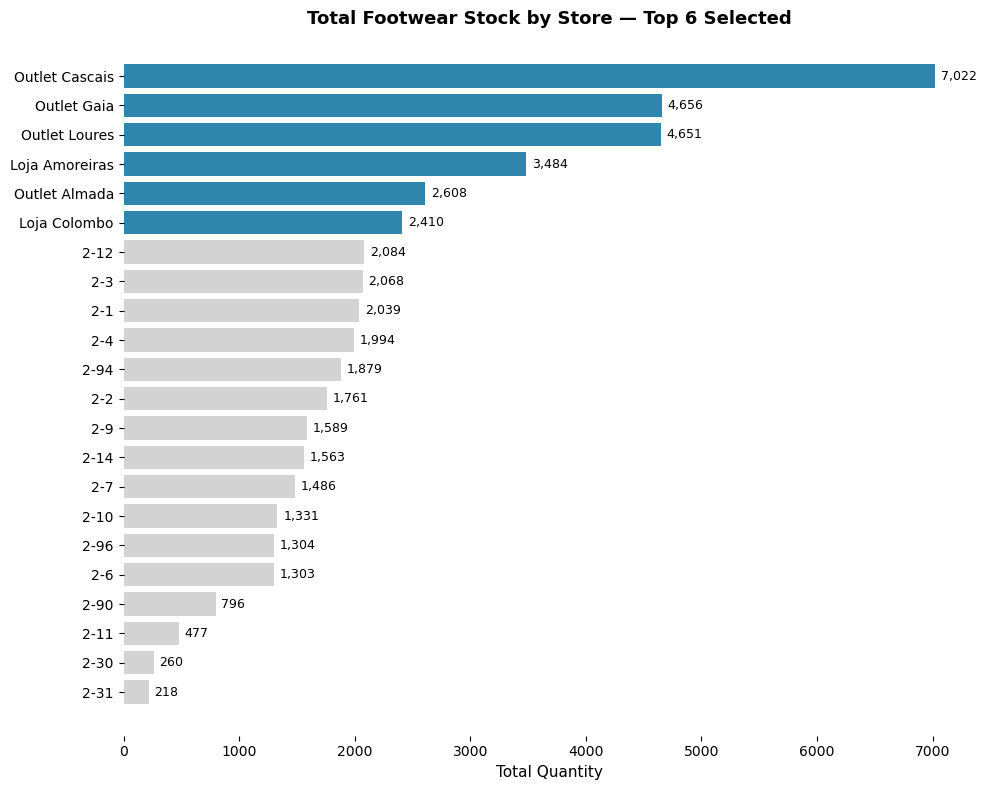

In [32]:
# plot total footwear stock for the top 6 selected stores
top_n = 6
colors = ['#2E86AB' if i < top_n else '#D3D3D3' for i in range(len(store_quantity_filtered))]

plt.figure(figsize=(10, 8))
bars = plt.barh(store_quantity_filtered.index, store_quantity_filtered.values, color=colors)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
              va='center', fontsize=9)

plt.xlabel('Total Quantity', fontsize=11)
plt.title('Total Footwear Stock by Store — Top 6 Selected', fontsize=13, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [33]:
# filter the dataset to the selected stores, keeping hq as the stock source
SELECTED_STORES = ['5-52', '5-53', '5-50', '2-8', '5-51', '2-41']

df_work = df_work[df_work['STORE_ID'].isin(SELECTED_STORES + ['1-HQ'])].copy()

df_work['STORE_ID'].value_counts()

STORE_ID
1-HQ    13039
5-52     3760
5-53     2424
5-50     2272
2-8      2041
2-41     1794
5-51     1063
Name: count, dtype: int64

### Brand Representation

**Scope decision:** replenishment logic works at the brand level, not
individual reference/SKU, for this phase of the project. This matches a
simpler first version of the chatbot interaction ("replenish brand X at
store Y") and avoids reference-matching issues while the core flow is being
built.

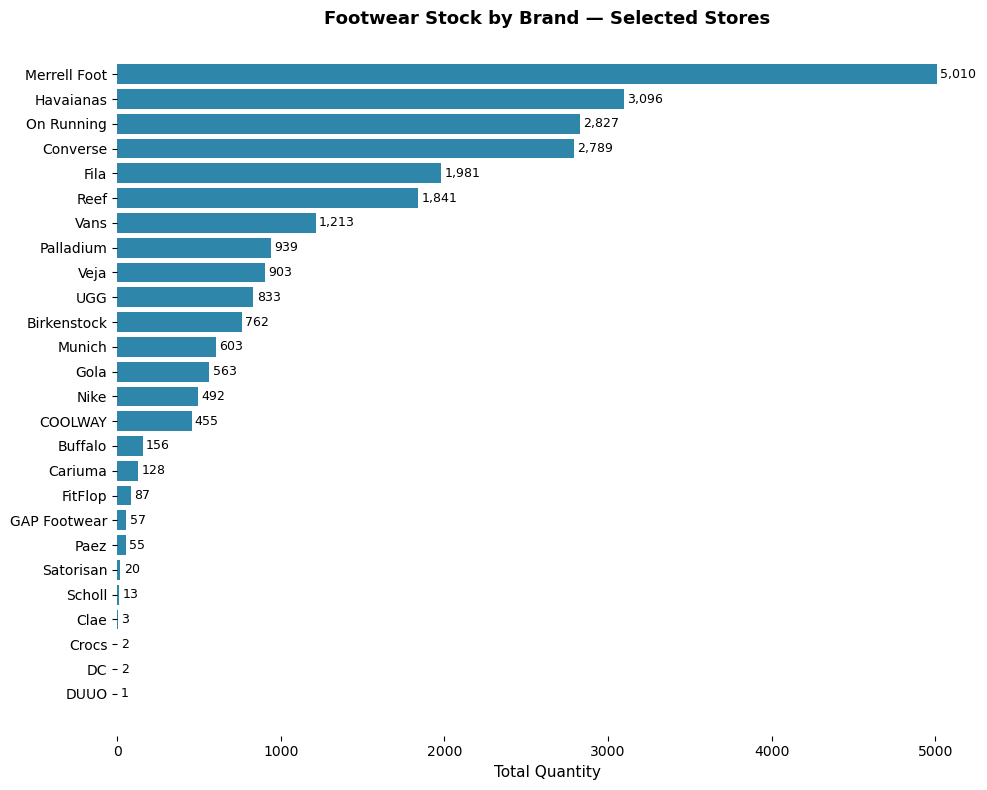

In [34]:
# plot brand representation across the selected stores (excluding hq)
brand_quantity = df_work[df_work['STORE_ID'] != '1-HQ'].groupby('BRAND')['QUANTITY'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
bars = plt.barh(brand_quantity.index, brand_quantity.values, color='#2E86AB')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
              va='center', fontsize=9)

plt.xlabel('Total Quantity', fontsize=11)
plt.title('Footwear Stock by Brand — Selected Stores', fontsize=13, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Brand Distribution Across Stores

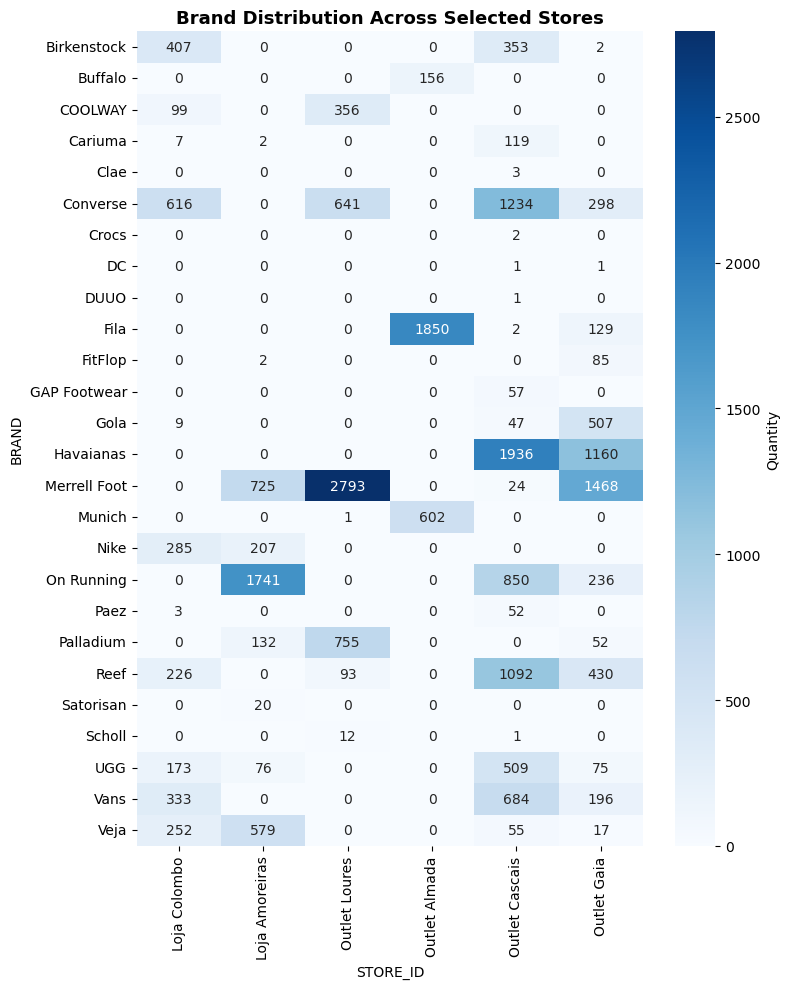

In [35]:
# build brand by store matrix, using display names for readability
pivot = df_work[df_work['STORE_ID'] != '1-HQ'].pivot_table(
    index='BRAND', columns='STORE_ID', values='QUANTITY', aggfunc='sum', fill_value=0
)

# apply the display names to columns (store_id stays the real key elsewhere)
pivot.columns = pivot.columns.map(lambda x: store_names.get(x, x))

plt.figure(figsize=(8, 10))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt='.0f', cbar_kws={'label': 'Quantity'})
plt.title('Brand Distribution Across Selected Stores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Replenishment Availability by Brand

This section checks, for each brand, whether the central warehouse (HQ) has
any stock available — since that is the only thing the replenishment logic
depends on.

In [36]:
# rebuild the matrix keeping hq, using real store_id (not display names)
pivot = df_work.pivot_table(
    index='BRAND', columns='STORE_ID', values='QUANTITY', aggfunc='sum', fill_value=0
)

# check, for each brand, whether hq has any stock available
hq_stock = pivot['1-HQ']
can_replenish = hq_stock > 0

replenish_status = pd.DataFrame({
    'HQ_Stock': hq_stock,
    'Can_Replenish': can_replenish.map({True: 'Yes', False: 'No — HQ out of stock'})
}).sort_values('HQ_Stock', ascending=False)

replenish_status

,HQ_Stock,Can_Replenish
BRAND,,
Merrell Foot,27472.0,Yes
Nike,16236.0,Yes
Gant,9375.0,Yes
UGG,7490.0,Yes
On Running,4594.0,Yes
Palladium,3746.0,Yes
Reef,2659.0,Yes
Buffalo,2647.0,Yes
Barbour,1887.0,Yes


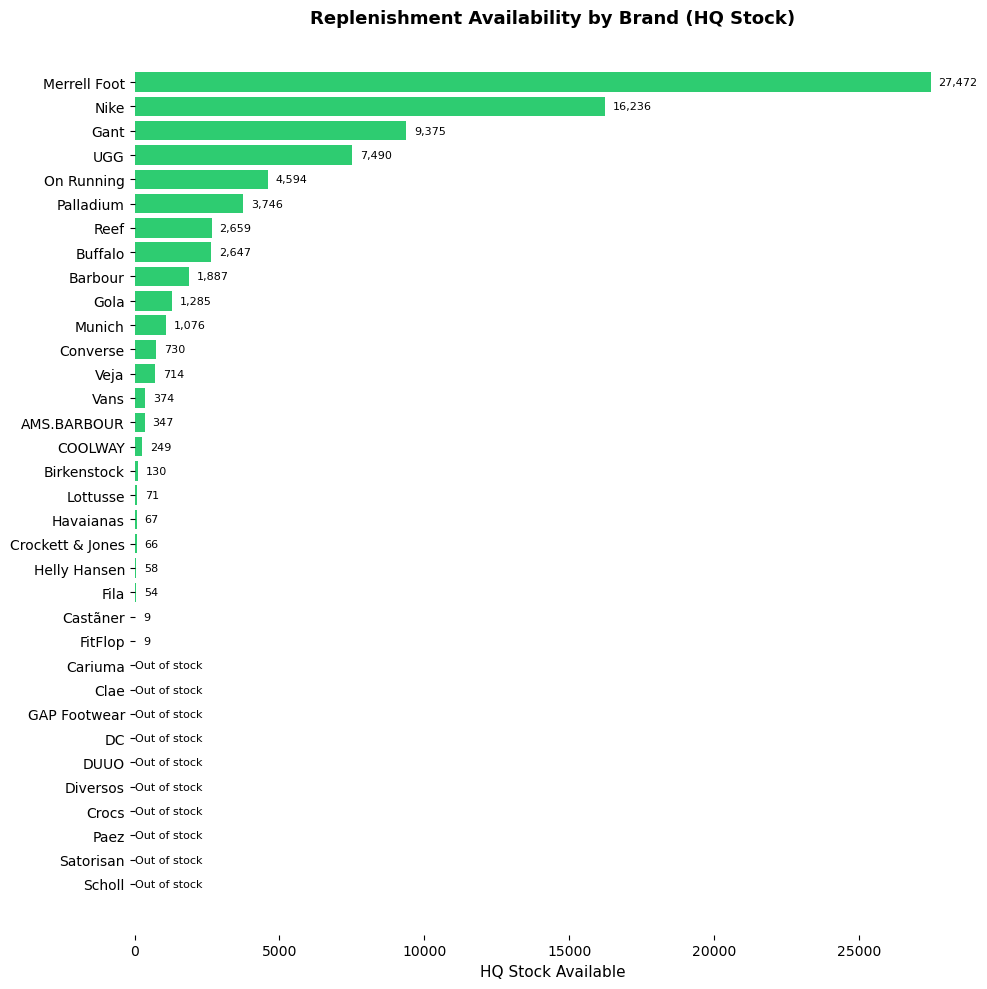

In [37]:
# visual version: green = can replenish, red = hq out of stock
plt.figure(figsize=(10, 10))
sorted_stock = hq_stock.sort_values(ascending=False)
colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in sorted_stock]

bars = plt.barh(sorted_stock.index, sorted_stock.values, color=colors)
plt.gca().invert_yaxis()

for bar, value in zip(bars, sorted_stock.values):
    label = f'{int(value):,}' if value > 0 else 'Out of stock'
    x_pos = bar.get_width() + (sorted_stock.max() * 0.01) if value > 0 else 5
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=8)

plt.xlabel('HQ Stock Available', fontsize=11)
plt.title('Replenishment Availability by Brand (HQ Stock)', fontsize=13, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [38]:
# save brand count before filtering, for reference (e.g. presentation slides)
brands_before = df_work['BRAND'].nunique()

In [39]:
# brands that exist in at least one of the 6 stores (excludes hq)
relevant_brands = df_work[df_work['STORE_ID'] != '1-HQ']['BRAND'].unique()

# filter the whole df_work (stores + hq) to keep only relevant brands
df_work = df_work[df_work['BRAND'].isin(relevant_brands)].copy()

df_work['BRAND'].nunique()

26

In [40]:
# check size values and data type
print(df_work['SIZE'].dtype)
df_work['SIZE'].unique()

object


array(['41', '42', '40', '44', '45', '43', '39', '46', '05', '06', '07',
       '08', '09', '10', '11', '12', '01', '02', '03', '04', '13', '37',
       '36', '38', '35', 'S', 'XS', 'M', '30', '31', '32', '33', '34',
       '045', '035', '26', '27', '47', '135', '105', '115', '085', '095',
       '075', '125', '065', '055', '4546', '2930', '3132', '3536', '4142',
       '4344', '2728', '3738', '3940', '3334', '2324', '2526', '22',
       'UNI', '28', '29', '40.5', '42.5', '18', '19', '20', '21', '23',
       '16', '17', '015', '025', '36.5', '37.5', '38.5', '3.5Y', '4.5Y',
       '4Y', '5.5Y', '5Y', '6.5Y', '6Y', '7Y', '44.5', '10C', '2C', '3C',
       '4C', '5C', '6C', '7C', '8C', '9C', '1.5Y', '11C', '12.5C', '12C',
       '13C', '1Y', '2.5Y', '3Y', '14', '15', '37,5', '38,5', '42,5',
       '43,5', '43.5', '19-20', '1920', '24', '25', '3031', '3839',
       '39-40', '41-42', '43-44', '35-36', '33-34', '37-38', '2829',
       '23-24', '29-30', '27-28', '45-46', '25-26', '1718', '31-3

### Size Cleaning

SIZE contains several different formats: plain sizes, comma-decimal sizes
(Portuguese format), dot-decimal sizes, dash and 4-digit ranges (an item
covering two sizes at once, common in slippers), 3-digit half-size codes
(e.g. '135' meaning 13.5), and non-numeric systems (letters like S/M, and
the US kids Y/C system). A first classification pass revealed that some
3-digit codes were silently absorbed by a naive "digits only" check,
producing impossible shoe sizes (e.g. '135' read as size 135). The function
below classifies and converts every format in a single pass, avoiding that
issue.

In [41]:
# classify each size format, to understand what needs converting
import re

def classify_size(s):
    s = str(s).strip()
    if re.fullmatch(r'\d+,\d+', s):
        return 'comma_decimal'
    if re.fullmatch(r'\d+\.\d+', s):
        return 'dot_decimal'
    if re.fullmatch(r'\d+-\d+', s):
        return 'dash_range'
    if re.fullmatch(r'\d{4}', s):
        return 'four_digit_range'
    if re.fullmatch(r'\d{3}', s):
        return 'three_digit_half_code'
    if re.fullmatch(r'\d{1,2}', s):
        return 'plain_size'
    if re.fullmatch(r'\d+(\.\d+)?[YC]', s):
        return 'kids_Y_C'
    if s in ['S', 'XS', 'M', 'L', 'UNI']:
        return 'letter'
    return 'other'

df_work['SIZE'].astype(str).apply(classify_size).value_counts()

SIZE
plain_size               16238
three_digit_half_code     5012
four_digit_range          1052
dot_decimal                606
dash_range                 208
letter                      75
kids_Y_C                    52
comma_decimal               36
Name: count, dtype: int64

**Conversion rules:**
- Comma and dot decimals -> straight float conversion
- Dash and 4-digit ranges (e.g. '39-40', '3940') -> average of the two sizes
- 3-digit half-size codes (e.g. '135') -> divide by 10 (13.5)
- Plain 1-2 digit sizes -> direct integer value
- Kids Y/C codes (US sizing, e.g. '5Y', '10C') -> letter stripped, number kept
  as-is. Not equivalent to EU adult sizing, but included as a documented
  simplification given the small share of the data (~0.2%)
- Letters (S, XS, M, UNI) have no numeric size to extract and are left as
  NaN, excluded from the numeric size grid for this phase — a small share
  of the data (~0.3%)

In [42]:
# convert every SIZE format into a single numeric scale (see rules above)
# note: kids Y/C codes (US sizing) are stripped of their letter and kept as-is,
# not equivalent to EU adult sizing, but included as a documented simplification
def convert_size_final(raw):
    s = str(raw).strip()
    if re.fullmatch(r'\d+,\d+', s):
        return float(s.replace(',', '.'))
    if re.fullmatch(r'\d+\.\d+', s):
        return float(s)
    if re.fullmatch(r'\d+-\d+', s):
        a, b = s.split('-')
        return (float(a) + float(b)) / 2
    if re.fullmatch(r'\d{4}', s):
        a, b = s[:2], s[2:]
        return (float(a) + float(b)) / 2
    if re.fullmatch(r'\d{3}', s):
        return int(s) / 10
    if re.fullmatch(r'\d{1,2}', s):
        return float(s)
    if re.fullmatch(r'\d+(\.\d+)?[YC]', s):
        return float(s[:-1])
    return np.nan

df_work['SIZE_NUMERIC'] = df_work['SIZE'].apply(convert_size_final)

# validation: confirm no impossible shoe sizes remain, and count what's left unconverted
print('Max size:', df_work['SIZE_NUMERIC'].max())
print('Unconverted rows:', df_work['SIZE_NUMERIC'].isna().sum())
df_work[df_work['SIZE_NUMERIC'].isna()]['SIZE'].value_counts()

Max size: 47.0
Unconverted rows: 75


SIZE
UNI    59
S       8
XS      7
M       1
Name: count, dtype: int64

**Note:** 75 rows (0.3%) use non-numeric or one-size labels (UNI, S, XS, M),
common for slippers and similar footwear. These are excluded from the
numeric size grid, as they don't fit a comparable size scale. They remain
in df_work and are still counted in all brand/store quantity totals.

## Replenishment Logic

The query functions used by the chatbot live in `src/replenishment.py`, so the
notebook and the Streamlit app share exactly the same implementation instead of
keeping two copies that can drift apart. This section documents what each
function does and shows it running against the dataset cleaned above.

The extraction was validated by comparing both the cleaned dataframe and the
function outputs against the original notebook implementation before the
duplicated code was removed.

In [43]:
# import the query functions from the project module
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src import replenishment as rp

# store type is needed by find_model_by_type and is part of data preparation
df_work['STORE_TYPE'] = df_work['WAREHOUSE'].map(rp.WAREHOUSE_TYPE_LABELS)

df_work.shape

(23279, 12)

### 1 - Stock by Store — Excel Export (by Brand)

Exports the stock of one store into an Excel workbook, one sheet per brand,
so each sheet only shows the size range relevant to that brand — easier to
read than one sheet with every brand mixed together.

Implementation: `rp.export_stock`. Generated files are written to `outputs/`.

In [44]:
rp.export_stock(df_work, store_input='Loja Amoreiras', brand_input='Nike')

'C:\\Users\\NelsonP\\Documents\\IronHack\\FinalProject\\outputs\\stock_export.xlsx'

### 2 - Find Reference — Text Search

Looks up where a reference exists across HQ and the 6 selected stores. Matches by prefix, since the last character of a reference is often an internal-system suffix that isn't always known upfront. Can be narrowed to a specific store or size. Returns a plain text answer (no Excel), meant to plug directly into the chatbot later.

Implementation: `rp.find_reference`.

In [45]:
print(rp.find_reference(df_work, 'DH2920'))

Reference 'DH2920' found in:
  HQ — DH2920-001: 3.5 (50 units), 4 (147 units), 4.5 (53 units), 5 (150 units), 5.5 (150 units), 6 (50 units), 6.5 (150 units), 7 (150 units)
  HQ — DH2920-001D: 36 (3 units), 36.5 (3 units), 37.5 (3 units), 38 (3 units), 38.5 (3 units), 39 (3 units), 40 (2 units)
  HQ — DH2920-111: 3.5 (88 units), 4 (297 units), 4.5 (103 units), 5 (300 units), 5.5 (300 units), 6 (100 units), 6.5 (300 units), 7 (300 units)
  HQ — DH2920-111D: 36 (2 units), 36.5 (3 units), 37.5 (5 units), 38 (4 units), 38.5 (4 units), 39 (4 units), 40 (4 units)
  Loja Colombo — DH2920-001: 4 (1 units), 5 (1 units), 5.5 (1 units), 6.5 (1 units), 7 (1 units)
  Loja Colombo — DH2920-111: 5.5 (1 units), 7 (1 units)
  Loja Colombo — DH2920-111D: 36 (1 units), 36.5 (1 units), 37.5 (1 units), 38 (1 units), 38.5 (1 units), 39 (1 units), 40 (1 units)
  Loja Amoreiras — DH2920-001: 3.5 (1 units), 4 (1 units), 5 (1 units), 5.5 (1 units), 6.5 (1 units), 7 (1 units)
  Loja Amoreiras — DH2920-111: 4 (1 u

### 3 - Quantity Summary

Plain quantity totals, no size breakdown and no Excel — meant for quick questions like "how much stock in store X" or "how much of brand Y across stores". The response shape adapts to what's specified: a single number for one store + one brand, a per-store breakdown for one brand, a per-brand breakdown for one store, and a general per-store breakdown otherwise. By default (no store given) this covers the 6 selected stores, not HQ — same convention as the other query functions; pass `store_input='HQ'` to include it.

Implementation: `rp.get_quantity`.

In [46]:
# single number: one store, one brand
print(rp.get_quantity(df_work, store_input='Loja Amoreiras', brand_input='Nike'))

Nike at Loja Amoreiras: 207 units.


In [47]:
# breakdown by store: one brand, all selected stores
print(rp.get_quantity(df_work, brand_input='Nike'))

Nike by store:
  Outlet Cascais: 0 units
  Outlet Gaia: 0 units
  Outlet Loures: 0 units
  Loja Amoreiras: 207 units
  Outlet Almada: 0 units
  Loja Colombo: 285 units
Total: 492 units


### 4 - Find Model by Store Type (HQ / Store / Outlet)

Groups the 6 selected stores plus HQ into three types, using the existing WAREHOUSE code (1 = hq, 2 = store, 5 = outlet). Lets you check where a model or brand exists across these groups — no scoring or decision logic, just the facts grouped by type, since the dataset has no sales/time data to base an automatic "needs to move to outlet" rule on. With no filters, shows a general overview by type.

Implementation: `rp.find_model_by_type`.

In [48]:
print(rp.find_model_by_type(df_work, brand_input='Nike'))

HQ:
  HQ: 16236 units
Store:
  Loja Colombo: 285 units
  Loja Amoreiras: 207 units


### 5 - Replenishment — Missing Sizes

For a given store, finds sizes that HQ has in stock but the store doesn't.
Works at reference level: only references the store already carries are
considered, since the goal is filling size gaps in an existing assortment,
not sending new models. Can be narrowed by brand and/or reference prefix.

`units_per_size` sets how many units to send per missing size, capped by what
HQ actually has. Left as `None`, the full available quantity is proposed.

The optional `allocated` argument holds stock already committed to earlier
replenishment documents in the same working session, keyed by
`(REFERENCE, SIZE)`. It is subtracted from HQ availability so the same units
are never proposed twice across different stores. The functions themselves
stay stateless — the session state lives in the Streamlit layer.

Implementation: `rp.find_replenishable_sizes` and
`rp.generate_replenishment_document`.

In [49]:
# one brand, one unit per missing size
rp.find_replenishable_sizes(df_work, 'Loja Amoreiras', brand_input='Nike', units_per_size=1)

,BRAND,REFERENCE,DESCRIPTION,ITEM_TYPE,SIZE,HQ_AVAILABLE,SEND_QTY
0,Nike,IR0952-100D,AIR FORCE 1 07 LV8 -WHITE/BLACK-WHITE,HOMEM,40,1,1
1,Nike,IV5732-002D,AIR FORCE 1 07-COLLEGE GREY/NEWSPRINT,HOMEM,42.5,2,1
2,Nike,IV5732-002D,AIR FORCE 1 07-COLLEGE GREY/NEWSPRINT,HOMEM,44,2,1
3,Nike,CW2288-111D,AIR FORCE 1 07-WHITE/WHITE,HOMEM,41,33,1
4,Nike,DH2920-001,AIR FORCE 1 LE (GS),JÚNIOR,4.5,53,1
5,Nike,DH2920-001,AIR FORCE 1 LE (GS),JÚNIOR,6,50,1
6,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,3.5,88,1
7,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,4.5,103,1
8,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,5,300,1
9,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,5.5,300,1


Without any brand or reference filter the result covers the whole store, which
is useful to gauge how large a full replenishment would be, but produces far
more lines than a single picking session would realistically handle.

In [50]:
result = rp.find_replenishable_sizes(df_work, 'Loja Amoreiras', units_per_size=1)
print(len(result), 'lines |', int(result['SEND_QTY'].sum()), 'units')
result.head(20)

442 lines | 442 units


,BRAND,REFERENCE,DESCRIPTION,ITEM_TYPE,SIZE,HQ_AVAILABLE,SEND_QTY
0,Merrell Foot,J068710C,AGILITY PEAK 5-WHITE/FLARE,SENHORA,3.5,1,1
1,Merrell Foot,J00003309C,AGILITY PEAK 6-BLACK,HOMEM,8.5,11,1
2,Merrell Foot,J00005072C,AGILITY PEAK 6-PIGEON,HOMEM,7.5,3,1
3,Merrell Foot,J00005072C,AGILITY PEAK 6-PIGEON,HOMEM,8,6,1
4,Merrell Foot,J00005072C,AGILITY PEAK 6-PIGEON,HOMEM,9.5,4,1
5,Merrell Foot,J00005072C,AGILITY PEAK 6-PIGEON,HOMEM,10.5,2,1
6,Merrell Foot,J00005072C,AGILITY PEAK 6-PIGEON,HOMEM,12,1,1
7,Merrell Foot,J00003318C,AGILITY PEAK 6-VERBENA,SENHORA,2.5,3,1
8,Merrell Foot,J00003318C,AGILITY PEAK 6-VERBENA,SENHORA,3,2,1
9,Merrell Foot,J00003318C,AGILITY PEAK 6-VERBENA,SENHORA,5.5,1,1


Generating the document is the only moment stock is considered committed. The
returned `allocated` record is passed back into later queries so the same units
are never proposed twice — in the app this record lives in `st.session_state`.

In [51]:
filename, allocated = rp.generate_replenishment_document(
    df_work, 'Loja Amoreiras', brand_input='Nike', units_per_size=1
)

print(filename)
print(f'{len(allocated)} reference/size pairs committed')

C:\Users\NelsonP\Documents\IronHack\FinalProject\outputs\replenishment_2-8.xlsx
56 reference/size pairs committed


In [52]:
# the same query after committing: sizes already allocated are gone
rp.find_replenishable_sizes(
    df_work, 'Loja Colombo', brand_input='Nike', allocated=allocated, units_per_size=1
).head(10)

,BRAND,REFERENCE,DESCRIPTION,ITEM_TYPE,SIZE,HQ_AVAILABLE,SEND_QTY
0,Nike,CW2288-111D,AIR FORCE 1 07-WHITE/WHITE,HOMEM,40,7,1
1,Nike,CW2288-111D,AIR FORCE 1 07-WHITE/WHITE,HOMEM,41,32,1
2,Nike,DH2920-001,AIR FORCE 1 LE (GS),JÚNIOR,3.5,50,1
3,Nike,DH2920-001,AIR FORCE 1 LE (GS),JÚNIOR,4.5,52,1
4,Nike,DH2920-001,AIR FORCE 1 LE (GS),JÚNIOR,6,49,1
5,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,3.5,87,1
6,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,4,297,1
7,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,4.5,102,1
8,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,5,299,1
9,Nike,DH2920-111,AIR FORCE 1 LE (GS),JÚNIOR,6,99,1
